## 0: import data
Both 2023 catalogs (Netflix and Amazon Prime) are analysed the same way as in `analysis_2022.ipynb`, followed by a comparison against the 2022 snapshots (section 8).

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

netflix = pd.read_csv("content_libraries/netflix_2023/netflix_titles_2023.csv")
amazon = pd.read_csv("content_libraries/amazon_2023/amazon_titles_2023.csv")

netflix_credits = pd.read_csv("content_libraries/netflix_2023/netflix_credits_2023.csv")
amazon_credits = pd.read_csv("content_libraries/amazon_2023/amazon_credits_2023.csv")

## 1.0: Info on the 2023 netflix titles dataset

In [39]:
netflix.head()
netflix.info()
netflix.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6137 entries, 0 to 6136
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    6137 non-null   object 
 1   title                 6137 non-null   object 
 2   type                  6137 non-null   object 
 3   description           6114 non-null   object 
 4   release_year          6137 non-null   int64  
 5   age_certification     3394 non-null   object 
 6   runtime               6137 non-null   int64  
 7   genres                6137 non-null   object 
 8   production_countries  6137 non-null   object 
 9   seasons               2306 non-null   float64
 10  imdb_id               5741 non-null   object 
 11  imdb_score            5669 non-null   float64
 12  imdb_votes            5653 non-null   float64
 13  tmdb_popularity       6061 non-null   float64
 14  tmdb_score            5885 non-null   float64
dtypes: float64(5), int64(

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,6137.000000,6137.000000,2306.000000,5669.000000,5.653000e+03,6061.000000,5885.000000
mean,2017.371843,76.381946,2.106678,6.540942,2.115029e+04,19.267196,6.633194
std,6.603620,39.086828,2.716844,1.135944,9.254225e+04,51.291407,1.251610
min,1945.000000,0.000000,1.000000,1.500000,5.000000e+00,0.009442,0.500000
25%,2017.000000,44.000000,1.000000,5.800000,5.170000e+02,3.381000,6.000000
50%,2019.000000,80.000000,1.000000,6.600000,2.095000e+03,7.580000,6.791000
75%,2021.000000,105.000000,2.000000,7.300000,8.884000e+03,16.523000,7.400000
max,2023.000000,225.000000,44.000000,9.600000,2.684317e+06,1078.637000,10.000000


(6137, 15)
Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')
id                         0
title                      0
type                       0
description               23
release_year               0
age_certification       2743
runtime                    0
genres                     0
production_countries       0
seasons                 3831
imdb_id                  396
imdb_score               468
imdb_votes               484
tmdb_popularity           76
tmdb_score               252
dtype: int64


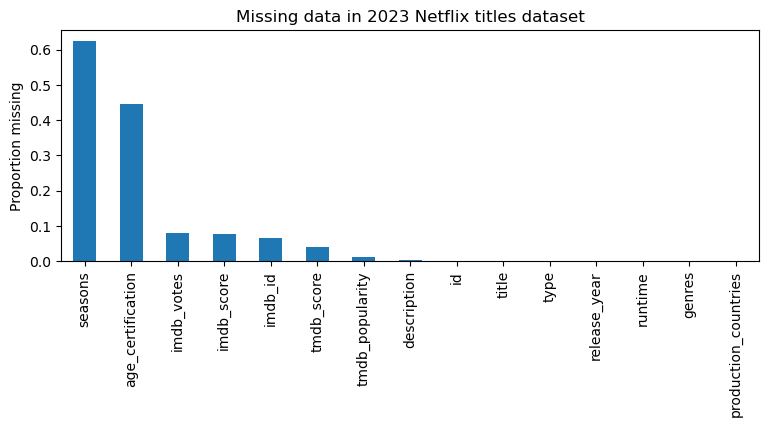

In [40]:
# how many null values?
print(netflix.shape)
print(netflix.columns)
print(netflix.isna().sum())

missing_netflix = netflix.isnull().mean().sort_values(ascending=False)

missing_netflix.plot(kind="bar", figsize=(9,3))
plt.ylabel("Proportion missing")
plt.title("Missing data in 2023 Netflix titles dataset")
plt.show()

## 1.1: Info on the 2023 amazon titles dataset

In [41]:
amazon.head()
amazon.info()
amazon.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10873 entries, 0 to 10872
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10873 non-null  object 
 1   title                 10873 non-null  object 
 2   type                  10873 non-null  object 
 3   description           10729 non-null  object 
 4   release_year          10873 non-null  int64  
 5   age_certification     3688 non-null   object 
 6   runtime               10873 non-null  int64  
 7   genres                10873 non-null  object 
 8   production_countries  10873 non-null  object 
 9   seasons               1551 non-null   float64
 10  imdb_id               10172 non-null  object 
 11  imdb_score            9765 non-null   float64
 12  imdb_votes            9753 non-null   float64
 13  tmdb_popularity       10302 non-null  float64
 14  tmdb_score            8747 non-null   float64
dtypes: float64(5), int6

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,10873.000000,10873.000000,1551.000000,9765.000000,9.753000e+03,10302.000000,8747.000000
mean,2004.077807,85.869033,2.661509,5.970558,8.973232e+03,7.614083,5.977729
std,24.883711,34.156332,3.719633,1.362815,4.897767e+04,45.845289,1.512941
min,1912.000000,0.000000,1.000000,1.100000,5.000000e+00,0.000153,0.500000
25%,2002.000000,65.000000,1.000000,5.100000,1.190000e+02,1.327250,5.066500
50%,2015.000000,89.000000,1.000000,6.100000,4.880000e+02,2.658500,6.000000
75%,2019.000000,102.000000,3.000000,7.000000,2.493000e+03,6.185000,6.983000
max,2023.000000,940.000000,53.000000,9.900000,2.081757e+06,3187.531000,10.000000


(10873, 15)
Index(['id', 'title', 'type', 'description', 'release_year',
       'age_certification', 'runtime', 'genres', 'production_countries',
       'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity',
       'tmdb_score'],
      dtype='object')
id                         0
title                      0
type                       0
description              144
release_year               0
age_certification       7185
runtime                    0
genres                     0
production_countries       0
seasons                 9322
imdb_id                  701
imdb_score              1108
imdb_votes              1120
tmdb_popularity          571
tmdb_score              2126
dtype: int64


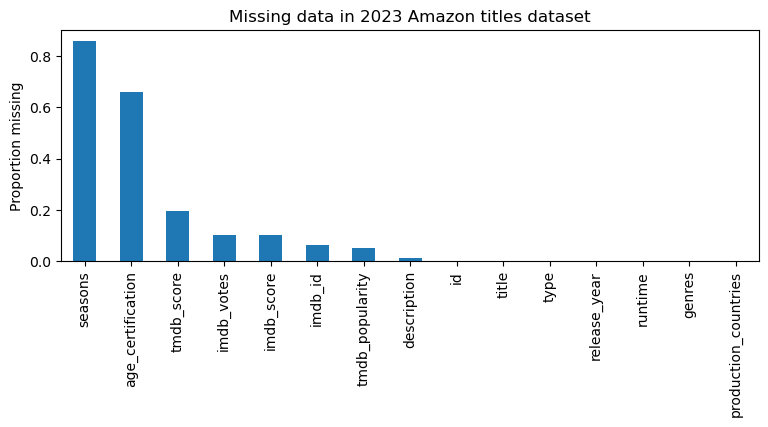

In [42]:
# how many null values?
print(amazon.shape)
print(amazon.columns)
print(amazon.isna().sum())

missing_amazon = amazon.isnull().mean().sort_values(ascending=False)

missing_amazon.plot(kind="bar", figsize=(9,3))
plt.ylabel("Proportion missing")
plt.title("Missing data in 2023 Amazon titles dataset")
plt.show()

## 1.2: Info on the 2023 credits datasets

In [43]:
for name, df in [("Netflix", netflix_credits), ("Amazon", amazon_credits)]:
    print(name, df.shape)
    print(df.isna().mean().round(3).to_dict())
    print(df["role"].value_counts().to_dict())
    print("credits per title:", round(len(df) / df["id"].nunique(), 2))
    print()

Netflix (81355, 5)
{'person_id': 0.0, 'id': 0.0, 'name': 0.0, 'character': 0.133, 'role': 0.0}
{'ACTOR': 76570, 'DIRECTOR': 4785}
credits per title: 14.06

Amazon (140553, 5)
{'person_id': 0.0, 'id': 0.0, 'name': 0.0, 'character': 0.127, 'role': 0.0}
{'ACTOR': 131164, 'DIRECTOR': 9389}
credits per title: 14.29



## 2.0: Combine the two datasets

In [44]:
netflix["service"] = "Netflix"
amazon["service"] = "Amazon Prime"
catalog = pd.concat([netflix, amazon], ignore_index=True)

## 3.0: Distribution of movies and TV shows for both services

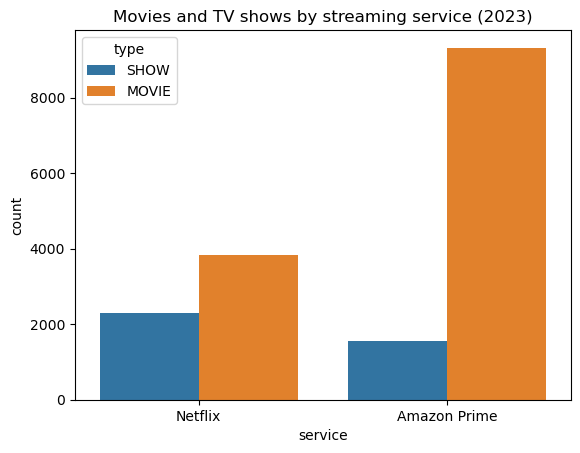

In [45]:
sns.countplot(data=catalog, x="service", hue="type")
plt.title("Movies and TV shows by streaming service (2023)")
plt.show()

## 3.1 Percentage of difference in movie and series for each service

In [46]:
pd.crosstab(
    catalog["service"],
    catalog["type"],
    normalize="index"
) * 100

type,MOVIE,SHOW
service,,
Amazon Prime,85.735308,14.264692
Netflix,62.424637,37.575363


## 4.0 Age of the content available

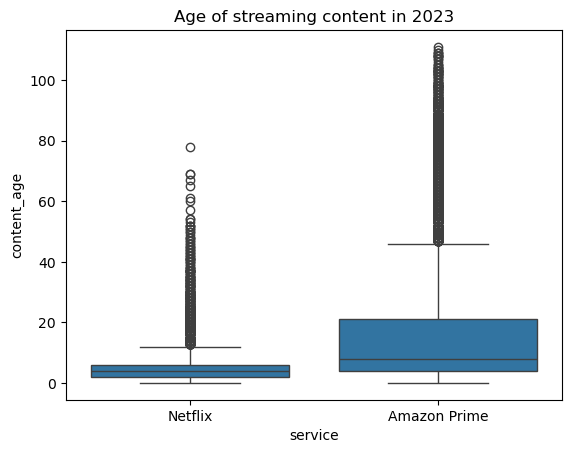

service
Amazon Prime    2004.077807
Netflix         2017.371843
Name: release_year, dtype: float64

In [47]:
catalog["content_age"] = 2023 - catalog["release_year"]

sns.boxplot(data=catalog, x="service", y="content_age")
plt.title("Age of streaming content in 2023")
plt.show()

# average release year
catalog.groupby("service")["release_year"].mean()

## 5.0 Content quality based on imdb rating

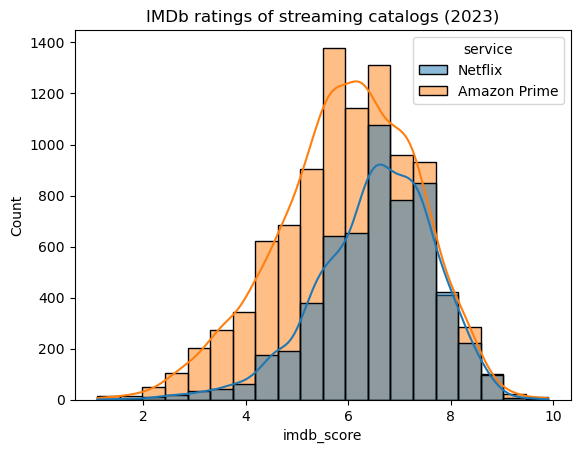

,mean,median,std,count
service,,,,
Amazon Prime,5.970558,6.1,1.362815,9765
Netflix,6.540942,6.6,1.135944,5669


In [48]:
sns.histplot(
    data=catalog,
    x="imdb_score",
    hue="service",
    kde=True,
    bins=20
)

plt.title("IMDb ratings of streaming catalogs (2023)")
plt.show()


catalog.groupby("service")["imdb_score"].agg(
    ["mean", "median", "std", "count"]
)

# not sufficient: if catalog increases but the number of high-rated titles
# stays the same, it should not be punished with a lower average rating

## 5.1 Create upper bound for high-quality content measure

In [49]:
# Define what high_quality is in this case
catalog["high_quality"] = (
    (catalog["imdb_score"] >= 7) &
    (catalog["imdb_votes"] >= 7000)
)

high_quality_stats = (
    catalog.groupby("service")
    .agg(
        total_titles=("imdb_id", "count"),
        high_quality_titles=("high_quality", "sum"),
        high_quality_share=("high_quality", "mean")
    )
)

high_quality_stats["high_quality_share"] *= 100

high_quality_stats.round(2)

# - high_quality_share:
#   What proportion of the catalog is highly rated?
# - high_quality_titles:
#   How many highly rated titles can consumers access?

,total_titles,high_quality_titles,high_quality_share
service,,,
Amazon Prime,10172,641,5.90
Netflix,5741,812,13.23


In [50]:
# Bayesian/weighted rating
# - we give more weight to imdb scores that have more reviews

# Overall average IMDb score
C = catalog["imdb_score"].mean()

# prior strength: the title's own IMDb score and the overall average each get roughly 50% weight (needs defined)
m = 3000

# Bayesian weighted IMDb score
catalog["weighted_imdb"] = (
    (catalog["imdb_votes"] / (catalog["imdb_votes"] + m))
    * catalog["imdb_score"]
    +
    (m / (catalog["imdb_votes"] + m))
    * C
)

catalog.groupby("service")["weighted_imdb"].mean().round(2)

service
Amazon Prime    6.21
Netflix         6.43
Name: weighted_imdb, dtype: float64

In [51]:
# answers: What is the overall quality of the catalog when we account for the reliability of IMDb ratings?
quality_comparison = (
    catalog.groupby("service")
    .agg(
        number_of_titles=("imdb_id", "count"),
        average_imdb=("imdb_score", "mean"),
        average_weighted_imdb=("weighted_imdb", "mean"),
        median_imdb_votes=("imdb_votes", "median"),
        high_quality_titles=("high_quality", "sum"),
        high_quality_share=("high_quality", "mean")
    )
)

quality_comparison["high_quality_share"] *= 100

quality_comparison.round(2)

,number_of_titles,average_imdb,average_weighted_imdb,median_imdb_votes,high_quality_titles,high_quality_share
service,,,,,,
Amazon Prime,10172,5.97,6.21,488.0,641,5.90
Netflix,5741,6.54,6.43,2095.0,812,13.23


## 6.0 Genre distribution across services

In [52]:
catalog["genres"] = catalog["genres"].fillna("[]")
catalog["genres"] = catalog["genres"].apply(ast.literal_eval)

genres = catalog.explode("genres")

genres["genres"] = genres["genres"].str.strip()

# number of movies and tv shows in each genre
genre_counts = genres.groupby("genres").size().sort_values(ascending=False)

print(genre_counts)

genres
drama            8631
comedy           5834
thriller         3735
action           3202
romance          2914
crime            2358
documentation    2298
horror           1621
family           1540
scifi            1360
fantasy          1294
animation        1261
european         1138
music             771
history           739
western           490
war               488
sport             467
reality           430
dtype: int64


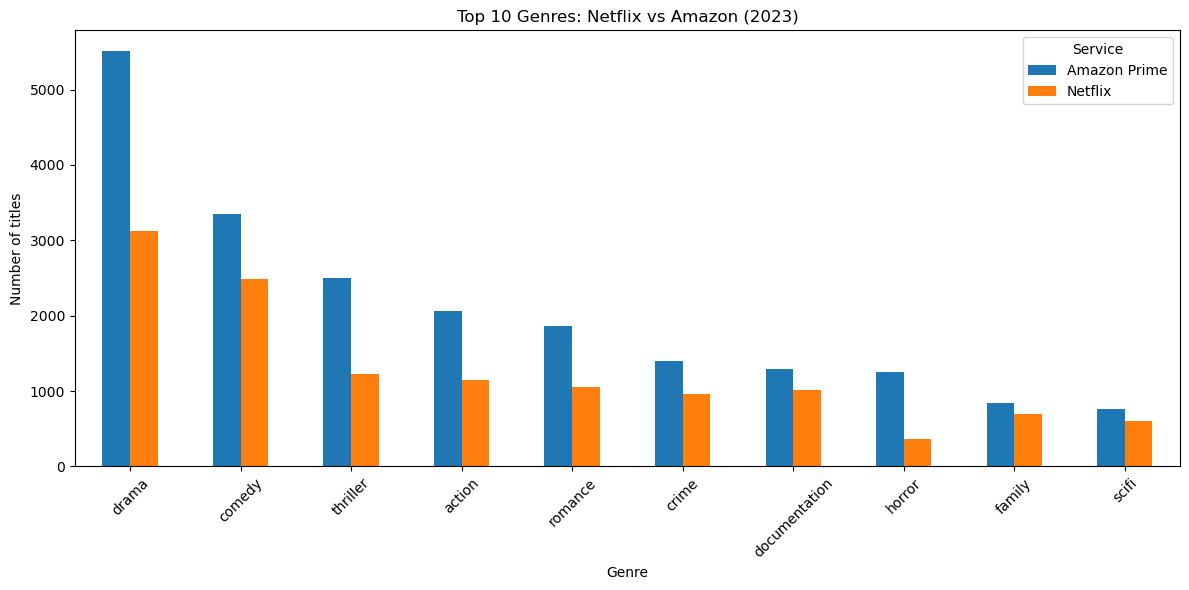

In [53]:
# number of tv shows and movies across genres
# note: a movie or a show can have multiple genres
genre_counts = genres.groupby(["genres", "service"]).size().unstack(fill_value=0)
top_genres = genre_counts.sum(axis=1).sort_values(ascending=False).head(10).index

genre_counts.loc[top_genres].plot(kind="bar", figsize=(12, 6))

plt.xlabel("Genre")
plt.ylabel("Number of titles")
plt.title("Top 10 Genres: Netflix vs Amazon (2023)")
plt.xticks(rotation=45)
plt.legend(title="Service")
plt.tight_layout()
plt.show()

## 6.1 Which genre provide the highest-quality content?

In [54]:
# based on imdb_score
genre_ratings = (
    genres.groupby(["genres", "service"])["imdb_score"]
    .mean()
    .unstack()
)

genre_ratings

service,Amazon Prime,Netflix
genres,,
action,5.658690,6.443490
animation,6.508214,6.759724
comedy,5.987359,6.441127
crime,5.995095,6.659318
documentation,6.969726,7.016631
drama,6.107535,6.633445
european,6.250201,6.537634
family,6.156134,6.404846
fantasy,5.990953,6.610107


In [55]:
# based on the bayesian weighted score
genre_ratings_weighted = (
    genres.groupby(["genres", "service"])["weighted_imdb"]
    .mean()
    .unstack()
    .round(2)
)
genre_ratings_weighted

service,Amazon Prime,Netflix
genres,,
action,6.17,6.42
animation,6.33,6.49
comedy,6.20,6.40
crime,6.30,6.54
documentation,6.32,6.54
drama,6.29,6.51
european,6.33,6.49
family,6.21,6.33
fantasy,6.21,6.51


## 7.0: Country of origin

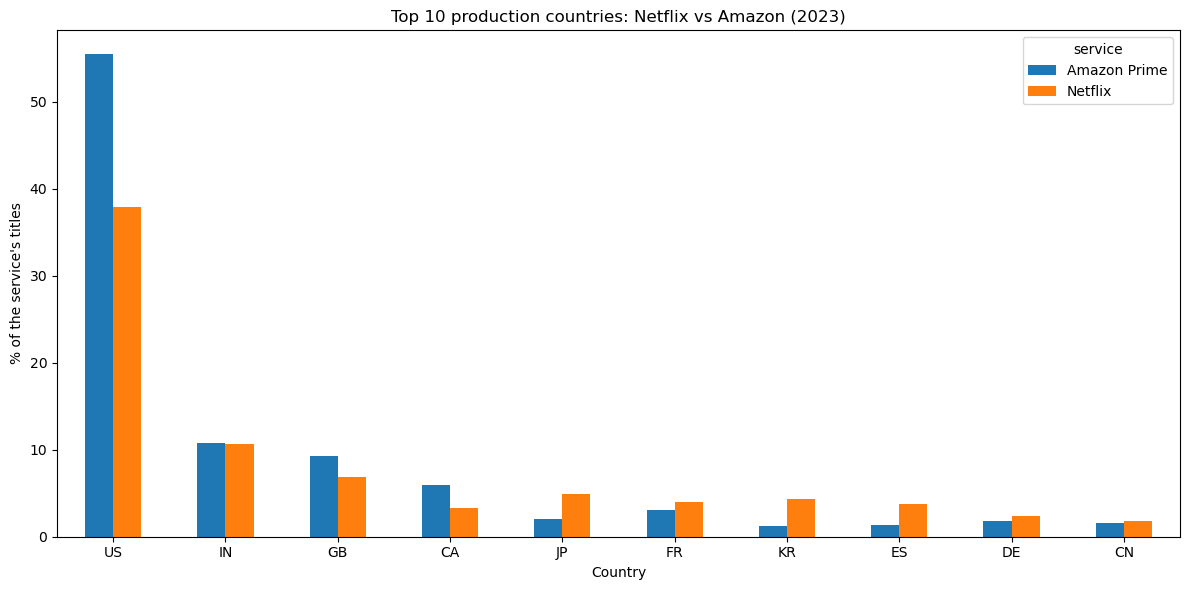

service,Amazon Prime,Netflix
production_countries,,
US,55.4,37.9
IN,10.7,10.7
GB,9.3,6.9
CA,6.0,3.3
JP,2.0,5.0
FR,3.0,3.9
KR,1.2,4.4
ES,1.4,3.8
DE,1.8,2.4


In [56]:
catalog["production_countries"] = catalog["production_countries"].fillna("[]").apply(ast.literal_eval)
countries = catalog.explode("production_countries")

# share of each service's titles that list a given country (a title can list several)
country_share = (
    countries.groupby(["production_countries", "service"]).size().unstack(fill_value=0)
    / catalog["service"].value_counts()
    * 100
)

top_countries = country_share.loc[country_share.sum(axis=1).sort_values(ascending=False).head(10).index]
top_countries.plot(kind="bar", figsize=(12, 6))
plt.xlabel("Country")
plt.ylabel("% of the service's titles")
plt.title("Top 10 production countries: Netflix vs Amazon (2023)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

top_countries.round(1)

## 8.0: Comparison 2022 vs 2023
For each service the 2022 and 2023 snapshots are joined on `id`, so every title is either **kept**, **removed** (only in 2022) or **added** (only in 2023). Comparing only the yearly averages hides this churn.

In [57]:
def load(service, year):
    df = pd.read_csv(f"content_libraries/{service.lower()}_{year}/{service.lower()}_titles_{year}.csv")
    df["service"] = "Netflix" if service == "Netflix" else "Amazon Prime"
    df["year"] = year
    return df

years = pd.concat(
    [load(s, y) for s in ["Netflix", "Amazon"] for y in [2022, 2023]],
    ignore_index=True,
)

# a few ids appear twice within one snapshot (e.g. Amazon 2022), keep the first
print("duplicate ids dropped:", years.duplicated(["service", "year", "id"]).sum())
years = years.drop_duplicates(["service", "year", "id"], ignore_index=True)

# titles added / removed between the two snapshots
churn_rows = []
for service, g in years.groupby("service"):
    ids_2022 = set(g.loc[g["year"] == 2022, "id"])
    ids_2023 = set(g.loc[g["year"] == 2023, "id"])
    churn_rows.append({
        "service": service,
        "titles_2022": len(ids_2022),
        "titles_2023": len(ids_2023),
        "kept": len(ids_2022 & ids_2023),
        "removed": len(ids_2022 - ids_2023),
        "added": len(ids_2023 - ids_2022),
    })
churn = pd.DataFrame(churn_rows).set_index("service")
churn["net_change_pct"] = ((churn["titles_2023"] / churn["titles_2022"] - 1) * 100).round(1)
churn["removed_pct_of_2022"] = (churn["removed"] / churn["titles_2022"] * 100).round(1)
churn["added_pct_of_2023"] = (churn["added"] / churn["titles_2023"] * 100).round(1)
churn

duplicate ids dropped: 3


,titles_2022,titles_2023,kept,removed,added,net_change_pct,removed_pct_of_2022,added_pct_of_2023
service,,,,,,,,
Amazon Prime,9868,10873,8065,1803,2808,10.2,18.3,25.8
Netflix,5850,6137,5067,783,1070,4.9,13.4,17.4


## 8.1: Movies and TV shows per year

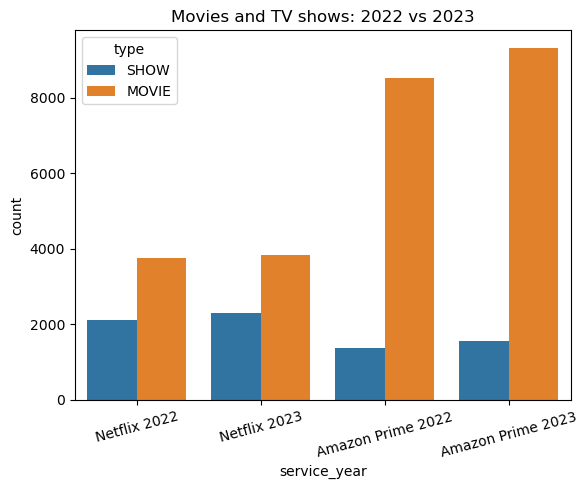

type,MOVIE,SHOW
service_year,,
Amazon Prime 2022,86.248480,13.751520
Amazon Prime 2023,85.735308,14.264692
Netflix 2022,64.000000,36.000000
Netflix 2023,62.424637,37.575363


In [58]:
years["service_year"] = years["service"] + " " + years["year"].astype(str)

sns.countplot(data=years, x="service_year", hue="type")
plt.title("Movies and TV shows: 2022 vs 2023")
plt.xticks(rotation=15)
plt.show()

pd.crosstab(years["service_year"], years["type"], normalize="index") * 100

## 8.2: Content age

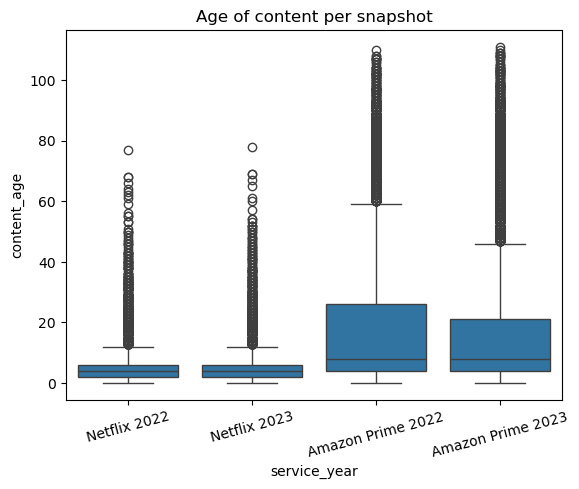

,release_year,content_age
service_year,,
Amazon Prime 2022,2001.35,20.65
Amazon Prime 2023,2004.08,18.92
Netflix 2022,2016.42,5.58
Netflix 2023,2017.37,5.63


In [59]:
years["content_age"] = years["year"] - years["release_year"]

sns.boxplot(data=years, x="service_year", y="content_age")
plt.title("Age of content per snapshot")
plt.xticks(rotation=15)
plt.show()

years.groupby("service_year")[["release_year", "content_age"]].mean().round(2)

## 8.3: Quality (same definitions as above)

In [60]:
years["high_quality"] = (years["imdb_score"] >= 7) & (years["imdb_votes"] >= 7000)

# use one shared prior mean so all four snapshots are comparable
C_all = years["imdb_score"].mean()
m = 3000
years["weighted_imdb"] = (
    (years["imdb_votes"] / (years["imdb_votes"] + m)) * years["imdb_score"]
    + (m / (years["imdb_votes"] + m)) * C_all
)

yearly_quality = (
    years.groupby(["service", "year"])
    .agg(
        number_of_titles=("id", "count"),
        average_imdb=("imdb_score", "mean"),
        average_weighted_imdb=("weighted_imdb", "mean"),
        median_imdb_votes=("imdb_votes", "median"),
        high_quality_titles=("high_quality", "sum"),
        high_quality_share=("high_quality", "mean")
    )
)
yearly_quality["high_quality_share"] *= 100
yearly_quality.round(2)

number_of_titles  average_imdb  average_weighted_imdb  \
service      year                                                          
Amazon Prime 2022              9868          5.98                   6.22   
             2023             10873          5.97                   6.21   
Netflix      2022              5850          6.51                   6.42   
             2023              6137          6.54                   6.42   

                   median_imdb_votes  high_quality_titles  high_quality_share  
service      year                                                              
Amazon Prime 2022              464.0                  554                5.61  
             2023              488.0                  641                5.90  
Netflix      2022             2233.5                  790               13.50  
             2023             2095.0                  812               13.23

## 8.4: Genres

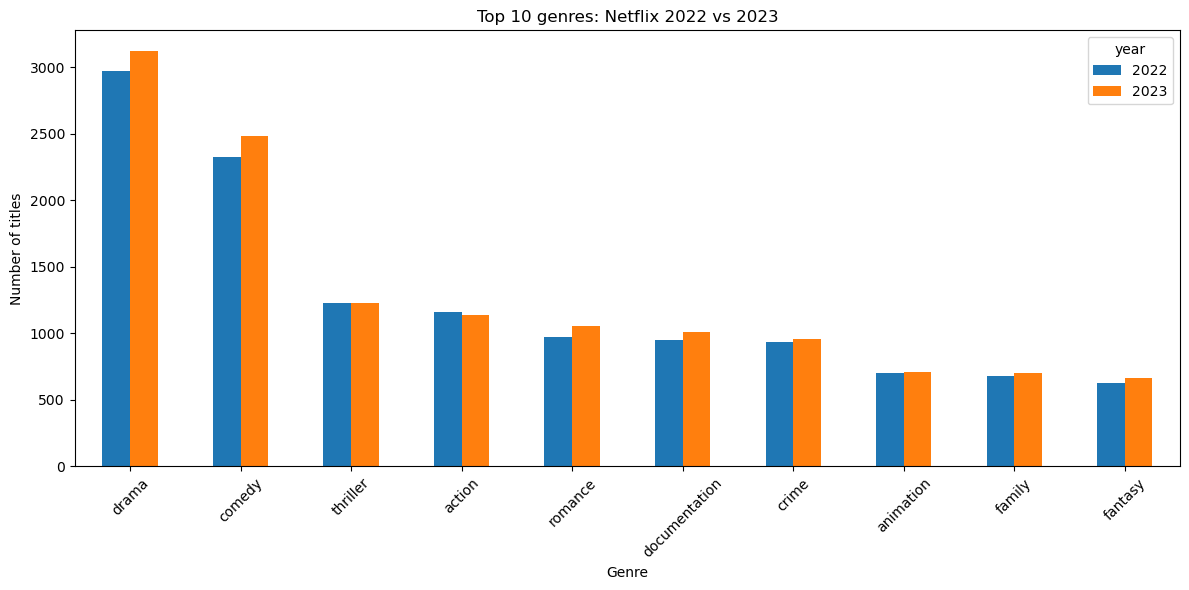

year,2022,2023,change,change_pct
genres,,,,
comedy,2325,2485,160,6.9
drama,2968,3120,152,5.1
romance,971,1054,83,8.5
documentation,952,1012,60,6.3
reality,234,278,44,18.8
fantasy,630,662,32,5.1
history,254,275,21,8.3
sport,170,191,21,12.4
crime,936,956,20,2.1


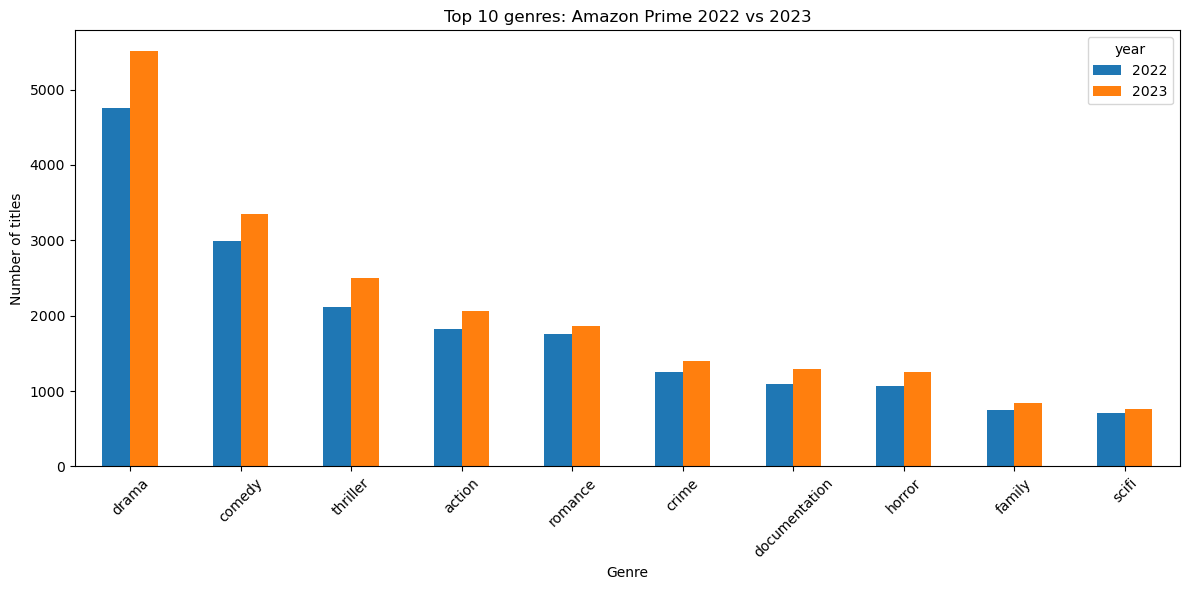

year,2022,2023,change,change_pct
genres,,,,
drama,4762,5511,749,15.7
thriller,2119,2506,387,18.3
comedy,2987,3349,362,12.1
action,1820,2062,242,13.3
horror,1065,1257,192,18.0
documentation,1096,1286,190,17.3
crime,1250,1402,152,12.2
romance,1751,1860,109,6.2
family,751,840,89,11.9


In [61]:
years["genres"] = years["genres"].fillna("[]").apply(ast.literal_eval)
genres_years = years.explode("genres")
genres_years["genres"] = genres_years["genres"].str.strip()

genre_year_counts = genres_years.groupby(["genres", "service", "year"]).size().unstack(["service", "year"], fill_value=0)

for service in ["Netflix", "Amazon Prime"]:
    g = genre_year_counts[service].copy()
    g["change"] = g[2023] - g[2022]
    g["change_pct"] = (g["change"] / g[2022] * 100).round(1)

    g.sort_values(2023, ascending=False).head(10)[[2022, 2023]].plot(kind="bar", figsize=(12, 6))
    plt.xlabel("Genre")
    plt.ylabel("Number of titles")
    plt.title(f"Top 10 genres: {service} 2022 vs 2023")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    display(g.sort_values("change", ascending=False))

## 8.5: Added vs removed titles
What kind of content leaves each catalog, and what replaces it?

In [62]:
# full outer join on id: one row per title with a status column
snap = {(s, y): g.set_index("id") for (s, y), g in years.groupby(["service", "year"])}

diffs = []
for service in ["Netflix", "Amazon Prime"]:
    d = snap[(service, 2022)].join(snap[(service, 2023)], how="outer", lsuffix="_22", rsuffix="_23")
    d["service"] = service
    d["status"] = np.select(
        [d["year_22"].isna(), d["year_23"].isna()],
        ["added", "removed"],
        default="kept",
    )
    diffs.append(d.reset_index())
diff = pd.concat(diffs, ignore_index=True)

# the attributes of a title come from 2023 if it exists there, otherwise from 2022
for col in ["title", "type", "release_year", "imdb_score", "imdb_votes", "high_quality"]:
    diff[col] = diff[col + "_23"].where(diff["status"] != "removed", diff[col + "_22"])

diff.drop(columns=["genres_22", "genres_23"]).to_csv("content_libraries/title_diff_2022_2023.csv", index=False)

diff.groupby(["service", "status"]).agg(
    titles=("id", "count"),
    share_movies=("type", lambda s: (s == "MOVIE").mean() * 100),
    median_release_year=("release_year", "median"),
    average_imdb=("imdb_score", "mean"),
    median_imdb_votes=("imdb_votes", "median"),
    high_quality_titles=("high_quality", "sum"),
).round(2)

titles  share_movies  median_release_year  average_imdb  \
service      status                                                             
Amazon Prime added      2808         83.26               2017.0          6.08   
             kept       8065         86.60               2015.0          5.93   
             removed    1803         84.69               2005.0          6.10   
Netflix      added      1070         68.50               2022.0          6.41   
             kept       5067         61.14               2019.0          6.57   
             removed     783         82.50               2014.0          6.29   

                      median_imdb_votes high_quality_titles  
service      status                                          
Amazon Prime added                874.5                 248  
             kept                 411.0                 393  
             removed              988.5                 168  
Netflix      added               1529.0                 114  
             kept                2242.0                 698  
             removed             4433.0                 135

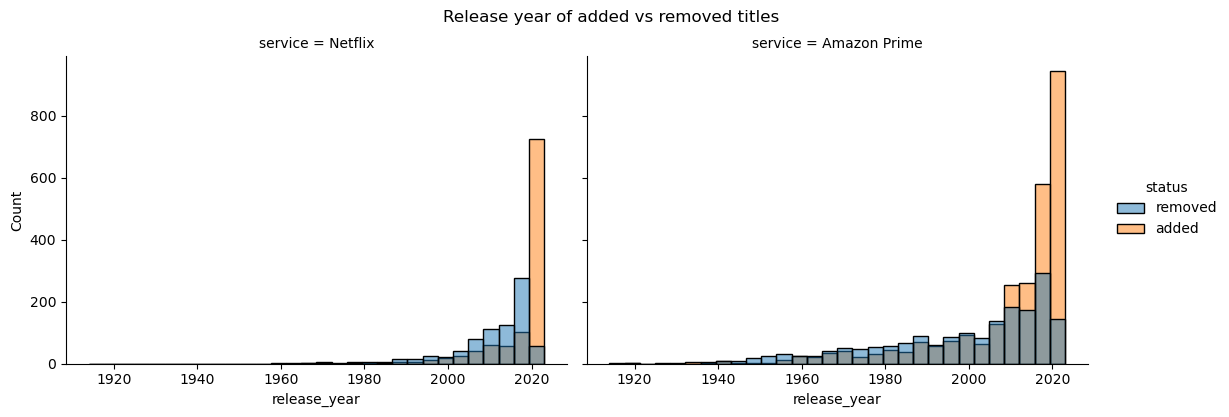

In [63]:
# release years of the added vs removed titles
g = sns.displot(
    data=diff[diff["status"] != "kept"],
    x="release_year",
    hue="status",
    col="service",
    bins=30,
    height=4,
    aspect=1.4,
)
g.figure.suptitle("Release year of added vs removed titles", y=1.03)
plt.show()

In [64]:
# share of each genre's 2022 titles that were removed by 2023
old = diff[diff["status"] != "added"].explode("genres_22")
old["genres_22"] = old["genres_22"].str.strip()

removal_rate = (
    old.groupby(["genres_22", "service"])["status"]
    .apply(lambda s: (s == "removed").mean() * 100)
    .unstack()
    .round(1)
)
removal_rate.loc[genre_year_counts.loc[:, (slice(None), 2022)].sum(axis=1).sort_values(ascending=False).head(15).index]

service,Amazon Prime,Netflix
genres,,
drama,19.3,14.4
comedy,19.3,12.1
thriller,20.0,20.0
action,20.8,18.9
romance,19.6,12.8
crime,22.0,17.9
documentation,16.4,9.2
horror,16.2,20.4
family,19.0,11.4


## 8.6: Titles that stayed (kept in both years)
How much did their IMDb numbers move, and how much of their metadata was rewritten?

In [65]:
kept = diff[diff["status"] == "kept"].copy()
kept["votes_change"] = kept["imdb_votes_23"] - kept["imdb_votes_22"]
kept["score_change"] = kept["imdb_score_23"] - kept["imdb_score_22"]

kept.groupby("service")[["votes_change", "score_change"]].describe().T.round(2)

service             Amazon Prime    Netflix
votes_change count       7144.00    4628.00
             mean         346.61    1149.38
             std         2664.91    5588.00
             min       -11824.00   -6101.00
             25%            6.00      28.00
             50%           24.00     129.00
             75%          105.00     520.25
             max       170515.00  163417.00
score_change count       7152.00    4642.00
             mean          -0.02       0.02
             std            0.34       0.16
             min           -4.60      -2.50
             25%            0.00       0.00
             50%            0.00       0.00
             75%            0.00       0.10
             max            4.10       1.60

In [66]:
# how many kept titles had an attribute changed between the snapshots?
attrs = ["title", "description", "release_year", "age_certification", "runtime", "genres", "production_countries", "seasons"]
changed = {}
for a in attrs:
    x, y = kept[a + "_22"].astype(str), kept[a + "_23"].astype(str)
    changed[a] = (x != y).groupby(kept["service"]).sum()
pd.DataFrame(changed).T

service,Amazon Prime,Netflix
title,93,57
description,509,206
release_year,884,266
age_certification,131,106
runtime,623,781
genres,3217,2185
production_countries,864,470
seasons,92,124


## 9.0: Only the difference between the years
This section ignores everything that stayed and looks only at what is **new in 2023** (status `added`) and what **left since 2022** (status `removed`). It reuses the `diff` table from section 8.5.

In [67]:
new_2023 = diff[diff["status"] == "added"].copy()
gone = diff[diff["status"] == "removed"].copy()

PROFILE_COLS = ["type", "release_year", "imdb_score", "imdb_votes", "high_quality"]

def profile(df):
    return pd.Series({
        "titles": len(df),
        "share_movies": (df["type"] == "MOVIE").mean() * 100,
        "median_release_year": df["release_year"].median(),
        "share_released_2022_or_later": (df["release_year"] >= 2022).mean() * 100,
        "share_without_imdb_score": df["imdb_score"].isna().mean() * 100,
        "average_imdb": df["imdb_score"].mean(),
        "median_imdb_votes": df["imdb_votes"].median(),
        "high_quality_titles": df["high_quality"].sum(),
        "high_quality_share": df["high_quality"].mean() * 100,
    })

pd.concat(
    {"added in 2023": new_2023.groupby("service")[PROFILE_COLS].apply(profile),
     "removed since 2022": gone.groupby("service")[PROFILE_COLS].apply(profile)},
    names=["status"],
).round(2)

titles  share_movies  median_release_year  \
status             service                                                   
added in 2023      Amazon Prime  2808.0         83.26               2017.0   
                   Netflix       1070.0         68.50               2022.0   
removed since 2022 Amazon Prime  1803.0         84.69               2005.0   
                   Netflix        783.0         82.50               2014.0   

                                 share_released_2022_or_later  \
status             service                                      
added in 2023      Amazon Prime                         17.77   
                   Netflix                              59.16   
removed since 2022 Amazon Prime                          0.55   
                   Netflix                               0.51   

                                 share_without_imdb_score  average_imdb  \
status             service                                                
added in 2023      Amazon Prime                     11.22          6.08   
                   Netflix                           9.25          6.41   
removed since 2022 Amazon Prime                      6.05          6.10   
                   Netflix                           7.28          6.29   

                                 median_imdb_votes  high_quality_titles  \
status             service                                                
added in 2023      Amazon Prime              874.5                248.0   
                   Netflix                  1529.0                114.0   
removed since 2022 Amazon Prime              988.5                168.0   
                   Netflix                  4433.0                135.0   

                                 high_quality_share  
status             service                           
added in 2023      Amazon Prime                8.83  
                   Netflix                    10.65  
removed since 2022 Amazon Prime                9.32  
                   Netflix                    17.24

## 9.1: Quality of the new titles
Movies and shows separately, since their ratings are not comparable.

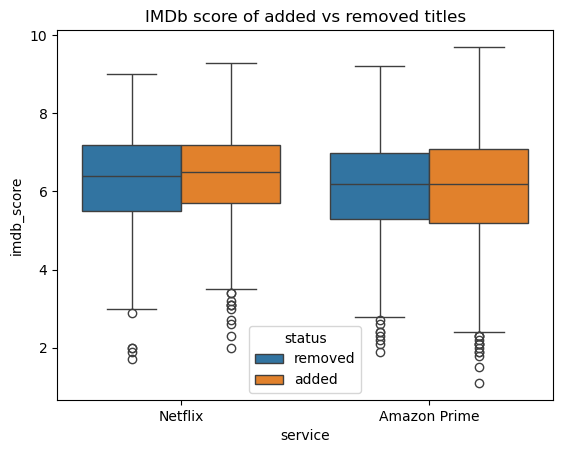

titles  average_imdb  median_imdb_votes  \
service      type  status                                             
Amazon Prime MOVIE added      2338          5.89              922.0   
                   removed    1527          5.94             1118.0   
             SHOW  added       470          7.09              669.0   
                   removed     276          7.04              500.0   
Netflix      MOVIE added       733          6.23             2115.5   
                   removed     646          6.18             6672.5   
             SHOW  added       337          6.80              892.5   
                   removed     137          6.84             1027.5   

                           high_quality_titles  high_quality_share  
service      type  status                                           
Amazon Prime MOVIE added                   179                7.66  
                   removed                 137                8.97  
             SHOW  added                    69               14.68  
                   removed                  31               11.23  
Netflix      MOVIE added                    81               11.05  
                   removed                 114               17.65  
             SHOW  added                    33                9.79  
                   removed                  21               15.33

In [68]:
changes = diff[diff["status"].isin(["added", "removed"])]

sns.boxplot(data=changes, x="service", y="imdb_score", hue="status", order=["Netflix", "Amazon Prime"])
plt.title("IMDb score of added vs removed titles")
plt.show()

changes.groupby(["service", "type", "status"]).agg(
    titles=("id", "count"),
    average_imdb=("imdb_score", "mean"),
    median_imdb_votes=("imdb_votes", "median"),
    high_quality_titles=("high_quality", "sum"),
    high_quality_share=("high_quality", lambda s: s.mean() * 100),
).round(2)

In [69]:
# the best new titles on each service (high_quality definition from 5.1)
new_2023[new_2023["high_quality"]].sort_values("imdb_votes", ascending=False).groupby("service").head(10)[
    ["service", "title", "type", "release_year", "imdb_score", "imdb_votes"]
].sort_values(["service", "imdb_votes"], ascending=[True, False])

,service,title,type,release_year,imdb_score,imdb_votes
7987,Amazon Prime,Pulp Fiction,MOVIE,1994.0,8.9,2081757.0
10757,Amazon Prime,The Wolf of Wall Street,MOVIE,2013.0,8.2,1437804.0
17290,Amazon Prime,Eternal Sunshine of the Spotless Mind,MOVIE,2004.0,8.3,1020305.0
10850,Amazon Prime,Good Will Hunting,MOVIE,1998.0,8.3,987571.0
8868,Amazon Prime,Raiders of the Lost Ark,MOVIE,1981.0,8.4,976566.0
10929,Amazon Prime,12 Angry Men,MOVIE,1957.0,9.0,801057.0
9281,Amazon Prime,Indiana Jones and the Last Crusade,MOVIE,1989.0,8.2,763526.0
17131,Amazon Prime,The King's Speech,MOVIE,2010.0,8.0,686908.0
15332,Amazon Prime,"Lock, Stock and Two Smoking Barrels",MOVIE,1998.0,8.2,589412.0
16099,Amazon Prime,Rocky,MOVIE,1976.0,8.1,588100.0


## 9.2: Genres of the new titles

,Titles 2022,Titles 2023,Added %,Removed %,Net added %,Metadata net titles,IMDb 2022,IMDb 2023,IMDb change,Rated 2022 %,Rated 2023 %
genres,,,,,,,,,,,
drama,2968,3120,9.47%,7.28%,+2.19%,+24,6.62,6.63,+0.01,95.2%,95.4%
comedy,2325,2485,7.23%,4.82%,+2.41%,+19,6.39,6.44,+0.05,95.4%,95.7%
thriller,1228,1229,4.31%,4.21%,+0.10%,-5,6.37,6.37,+0.01,96.1%,96.7%
action,1157,1140,3.81%,3.74%,+0.07%,-21,6.42,6.44,+0.02,95.9%,97.0%
romance,971,1054,3.33%,2.12%,+1.21%,+12,6.38,6.44,+0.06,98.4%,99.0%
documentation,952,1012,2.58%,1.50%,+1.08%,-3,7.01,7.02,+0.01,90.2%,91.5%
crime,936,956,3.45%,2.87%,+0.58%,-14,6.65,6.66,+0.01,97.1%,98.2%
animation,705,711,1.45%,1.15%,+0.31%,-12,6.70,6.76,+0.06,89.4%,91.8%
family,682,700,1.88%,1.33%,+0.55%,-14,6.33,6.40,+0.07,95.6%,97.3%


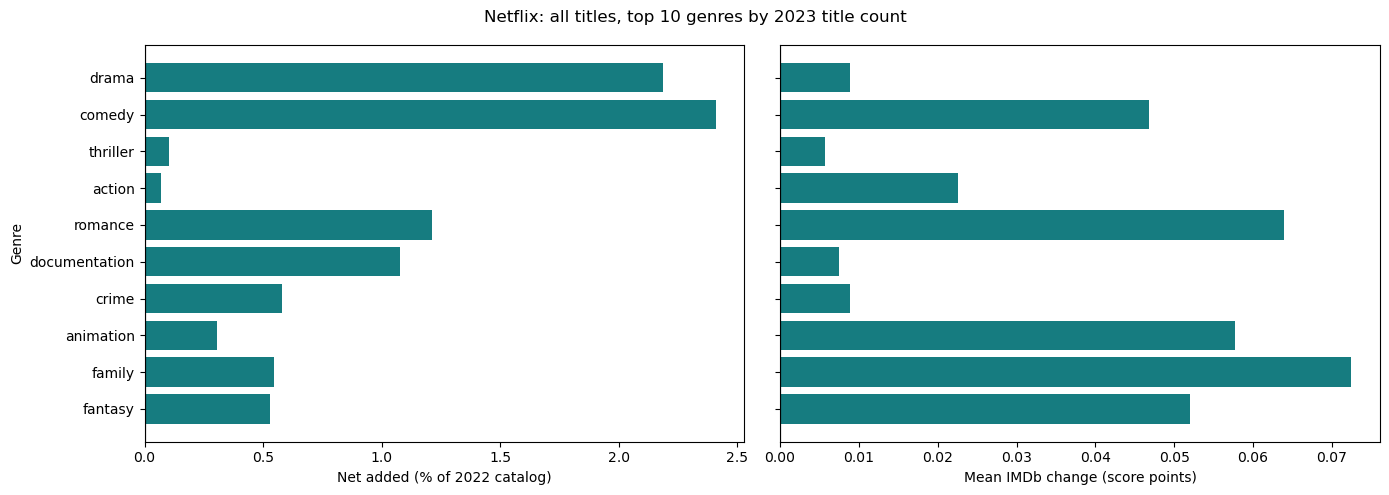

,Titles 2022,Titles 2023,Added %,Removed %,Net added %,Metadata net titles,IMDb 2022,IMDb 2023,IMDb change,Rated 2022 %,Rated 2023 %
genres,,,,,,,,,,,
drama,4762,5511,14.87%,9.33%,+5.53%,+203,6.13,6.11,-0.02,94.2%,94.2%
comedy,2987,3349,9.01%,5.83%,+3.18%,+48,5.99,5.99,-0.01,93.9%,92.6%
thriller,2119,2506,7.39%,4.30%,+3.09%,+82,5.54,5.51,-0.03,94.9%,95.1%
action,1820,2062,5.43%,3.83%,+1.60%,+84,5.67,5.66,-0.01,97.3%,96.3%
romance,1751,1860,4.31%,3.48%,+0.83%,+27,6.02,6.01,-0.00,98.1%,97.8%
crime,1250,1402,3.93%,2.79%,+1.15%,+39,6.00,6.00,-0.01,97.0%,97.4%
documentation,1096,1286,3.53%,1.82%,+1.70%,+22,6.99,6.97,-0.03,86.6%,88.1%
horror,1065,1257,3.40%,1.75%,+1.65%,+29,4.77,4.79,+0.02,94.0%,93.2%
family,751,840,2.04%,1.45%,+0.59%,+31,6.15,6.16,+0.01,96.4%,96.1%


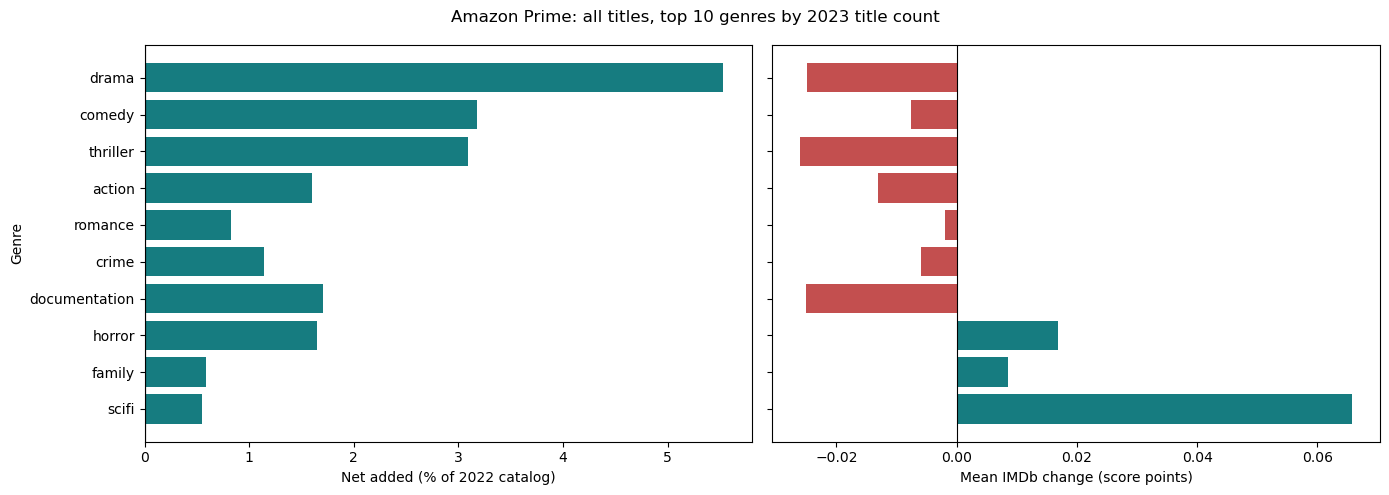

In [70]:
# "ALL", "MOVIE" or "SHOW": which titles the tables and charts below cover
GENRE_VIEW = "ALL"

snapshot_genres = pd.concat(
    [years, years.assign(type="ALL")], ignore_index=True
).explode("genres")
snapshot_genres["genres"] = snapshot_genres["genres"].str.strip()
snapshot_genres = snapshot_genres.dropna(subset=["genres"]).drop_duplicates(
    ["service", "type", "year", "id", "genres"]
)
genre_snapshot_stats = snapshot_genres.groupby(["service", "type", "genres", "year"]).agg(
    titles=("id", "size"),
    rated_titles=("imdb_score", "count"),
    mean_imdb=("imdb_score", "mean"),
).unstack("year")

genre_summary = pd.DataFrame(index=genre_snapshot_stats.index)
for year in [2022, 2023]:
    genre_summary[f"titles_{year}"] = genre_snapshot_stats["titles"][year].fillna(0).astype(int)
    genre_summary[f"rated_titles_{year}"] = genre_snapshot_stats["rated_titles"][year].fillna(0).astype(int)
    genre_summary[f"mean_imdb_{year}"] = genre_snapshot_stats["mean_imdb"][year]
    genre_summary[f"rated_pct_{year}"] = (
        genre_summary[f"rated_titles_{year}"] / genre_summary[f"titles_{year}"].replace(0, np.nan) * 100
    )

for status, genre_column, type_column in [
    ("added", "genres_23", "type_23"),
    ("removed", "genres_22", "type_22"),
]:
    status_titles = diff.loc[diff["status"] == status].copy()
    status_titles["type"] = status_titles[type_column]
    status_genres = pd.concat(
        [status_titles, status_titles.assign(type="ALL")], ignore_index=True
    ).explode(genre_column)
    status_genres[genre_column] = status_genres[genre_column].str.strip()
    status_genres = status_genres.dropna(subset=[genre_column]).drop_duplicates(
        ["service", "type", "id", genre_column]
    )
    status_counts = status_genres.groupby(["service", "type", genre_column]).size()
    status_counts.index = status_counts.index.set_names(["service", "type", "genres"])
    genre_summary[status] = status_counts.reindex(genre_summary.index, fill_value=0)

baseline_sizes = pd.concat(
    [years.loc[years["year"] == 2022], years.loc[years["year"] == 2022].assign(type="ALL")],
    ignore_index=True,
).groupby(["service", "type"]).size()
genre_summary["baseline_titles_2022"] = baseline_sizes.reindex(
    genre_summary.index.droplevel("genres")
).to_numpy()
for status in ["added", "removed"]:
    genre_summary[f"{status}_pct_of_2022_catalog"] = (
        genre_summary[status] / genre_summary["baseline_titles_2022"] * 100
    )
genre_summary["net_added_pct_of_2022_catalog"] = (
    (genre_summary["added"] - genre_summary["removed"])
    / genre_summary["baseline_titles_2022"] * 100
)
genre_summary["catalog_count_change"] = genre_summary["titles_2023"] - genre_summary["titles_2022"]
genre_summary["metadata_count_change"] = (
    genre_summary["catalog_count_change"] - (genre_summary["added"] - genre_summary["removed"])
)
genre_summary["mean_imdb_change"] = genre_summary["mean_imdb_2023"] - genre_summary["mean_imdb_2022"]

if GENRE_VIEW not in {"ALL", "MOVIE", "SHOW"}:
    raise ValueError('GENRE_VIEW must be "ALL", "MOVIE", or "SHOW"')

view_label = {"ALL": "all titles", "MOVIE": "movies", "SHOW": "series"}[GENRE_VIEW]
summary_columns = {
    "titles_2022": "Titles 2022",
    "titles_2023": "Titles 2023",
    "added_pct_of_2022_catalog": "Added %",
    "removed_pct_of_2022_catalog": "Removed %",
    "net_added_pct_of_2022_catalog": "Net added %",
    "metadata_count_change": "Metadata net titles",
    "mean_imdb_2022": "IMDb 2022",
    "mean_imdb_2023": "IMDb 2023",
    "mean_imdb_change": "IMDb change",
    "rated_pct_2022": "Rated 2022 %",
    "rated_pct_2023": "Rated 2023 %",
}
for service in ["Netflix", "Amazon Prime"]:
    service_summary = genre_summary.xs((service, GENRE_VIEW), level=("service", "type")).sort_values(
        "titles_2023", ascending=False
    )
    display(
        service_summary[list(summary_columns)].rename(columns=summary_columns).style
        .format({
            "Titles 2022": "{:.0f}", "Titles 2023": "{:.0f}",
            "Added %": "{:.2f}%", "Removed %": "{:.2f}%", "Net added %": "{:+.2f}%",
            "Metadata net titles": "{:+.0f}", "IMDb 2022": "{:.2f}", "IMDb 2023": "{:.2f}",
            "IMDb change": "{:+.2f}", "Rated 2022 %": "{:.1f}%", "Rated 2023 %": "{:.1f}%",
        }, na_rep="N/A")
        .background_gradient(cmap="RdYlGn", subset=["Net added %"], vmin=-6, vmax=6)
        .background_gradient(cmap="RdYlGn", subset=["IMDb change"], vmin=-0.15, vmax=0.15)
        .set_caption(f"{service}: {view_label}; additions/removals as % of the 2022 {view_label} catalog")
    )
    plotted_genres = service_summary.head(10).iloc[::-1]
    figure, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for axis, column, label in [
        (axes[0], "net_added_pct_of_2022_catalog", "Net added (% of 2022 catalog)"),
        (axes[1], "mean_imdb_change", "Mean IMDb change (score points)"),
    ]:
        values = plotted_genres[column]
        axis.barh(plotted_genres.index, values, color=np.where(values >= 0, "#167c80", "#c34f4f"))
        axis.axvline(0, color="black", linewidth=0.8)
        axis.set_xlabel(label)
    axes[0].set_ylabel("Genre")
    figure.suptitle(f"{service}: {view_label}, top 10 genres by 2023 title count")
    figure.tight_layout()
    plt.show()

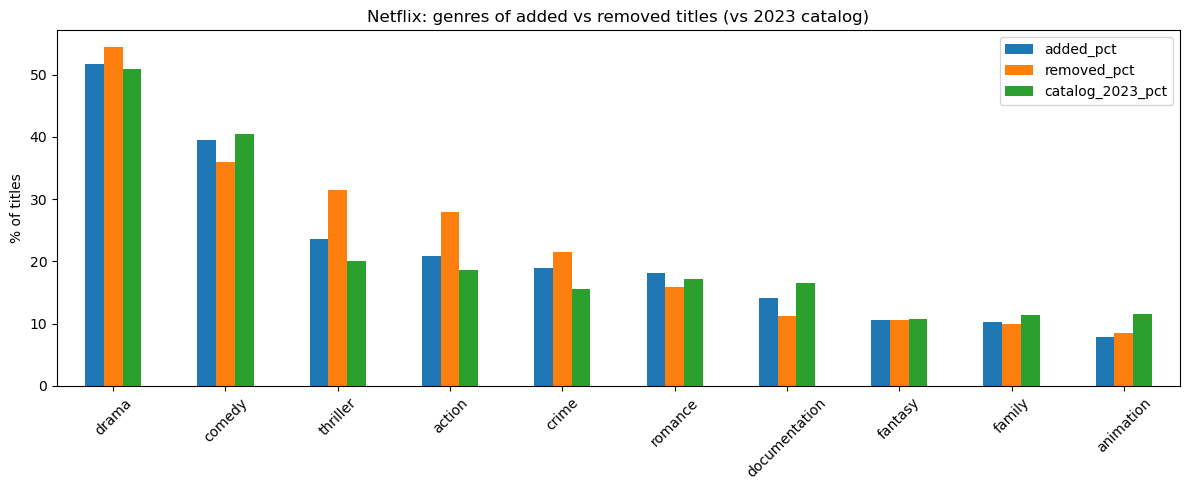

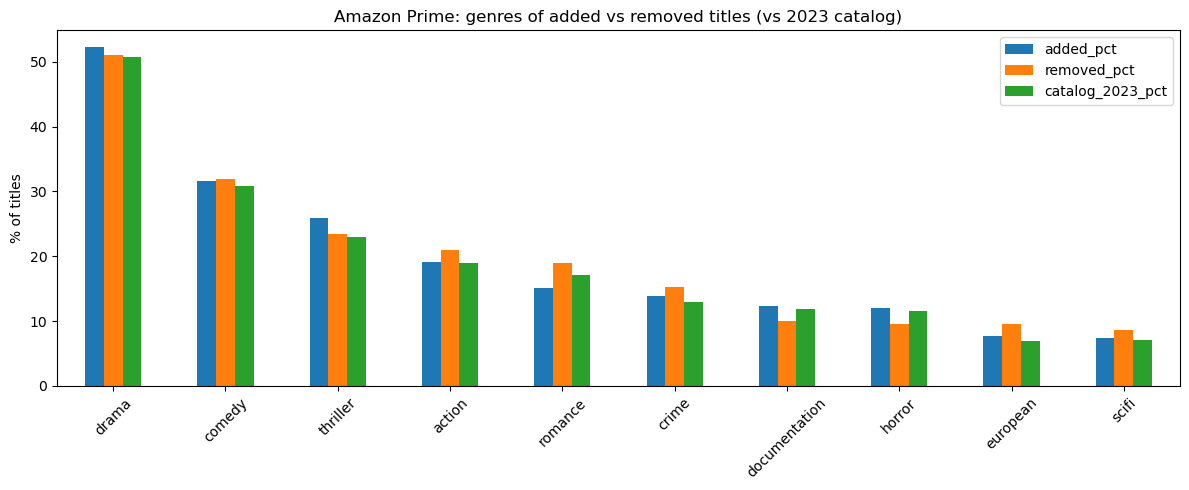

(service   Amazon Prime  Netflix
 thriller           2.9      3.5
 crime              0.9      3.3
 action             0.1      2.3
 romance           -2.0      1.0
 drama              1.6      0.9
 reality            0.4      0.7
 sport              0.5      0.5
 western           -2.2      0.1,
 service        Amazon Prime  Netflix
 thriller                2.9      3.5
 drama                   1.6      0.9
 fantasy                 1.2     -0.1
 comedy                  0.9     -1.0
 crime                   0.9      3.3
 european                0.7     -2.6
 documentation           0.6     -2.4
 sport                   0.5      0.5)

In [71]:
def genre_mix(df, col):
    e = df.explode(col)
    e[col] = e[col].str.strip()
    return e.groupby([col, "service"]).size().unstack(fill_value=0)

added_genres = genre_mix(new_2023, "genres_23")
removed_genres = genre_mix(gone, "genres_22")

# share of the added / removed titles that carry each genre
added_pct = added_genres / new_2023["service"].value_counts() * 100
removed_pct = removed_genres / gone["service"].value_counts() * 100
# share of the whole 2023 catalog with that genre, as the baseline
base_pct = (genres_years[genres_years["year"] == 2023].groupby(["genres", "service"]).size().unstack(fill_value=0)
            / years[years["year"] == 2023]["service"].value_counts() * 100)

genre_compare = pd.concat(
    {"added_pct": added_pct, "removed_pct": removed_pct, "catalog_2023_pct": base_pct}, axis=1
)
genre_compare = genre_compare.fillna(0)

for service in ["Netflix", "Amazon Prime"]:
    top = genre_compare.xs(service, axis=1, level=1).sort_values("added_pct", ascending=False).head(10)
    top.plot(kind="bar", figsize=(12, 5))
    plt.ylabel("% of titles")
    plt.title(f"{service}: genres of added vs removed titles (vs 2023 catalog)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# genres over-represented among the new titles (added share minus catalog share, percentage points)
over = (genre_compare["added_pct"] - genre_compare["catalog_2023_pct"]).round(1)
over.sort_values("Netflix", ascending=False).head(8), over.sort_values("Amazon Prime", ascending=False).head(8)

## 9.3: Origin and age of the new titles

In [72]:
def country_mix(df, col):
    e = df.assign(**{col: df[col].fillna("[]").apply(ast.literal_eval)}).explode(col)
    return e.groupby([col, "service"]).size().unstack(fill_value=0) / df["service"].value_counts() * 100

country_diff = pd.concat(
    {"added_pct": country_mix(new_2023, "production_countries_23"),
     "removed_pct": country_mix(gone, "production_countries_22")}, axis=1
).fillna(0)
country_diff.loc[country_diff["added_pct"].sum(axis=1).sort_values(ascending=False).head(8).index].round(1)

added_pct          removed_pct        
service Amazon Prime Netflix Amazon Prime Netflix
US              56.6    38.5         64.7    57.3
GB              10.2     7.6         14.3    10.7
IN               4.9    11.3          4.9    12.9
CA               7.1     2.4          5.3     5.9
KR               2.5     4.4          0.4     1.1
FR               3.9     2.8          2.3     5.1
NG               1.9     3.6          0.1     2.0
JP               1.6     3.8          1.4     3.3

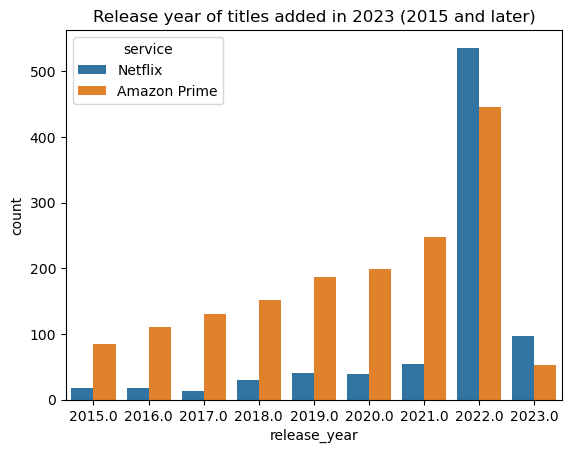

type,MOVIE,SHOW
service,,
Amazon Prime,83.262108,16.737892
Netflix,68.504673,31.495327


In [73]:
# release year of the new titles: are they recent releases or back-catalog?
sns.countplot(
    data=new_2023[new_2023["release_year"] >= 2015],
    x="release_year", hue="service",
)
plt.title("Release year of titles added in 2023 (2015 and later)")
plt.show()

# movies vs shows among the new titles
pd.crosstab(new_2023["service"], new_2023["type"], normalize="index") * 100

## 9.4: Caveat: the IMDb match can change for the same `id`
The `id` stays the same across years, but for some kept titles the `imdb_id` it points to changed, so a score change there can reflect a different IMDb entry and not a re-rating.

In [74]:
remapped = kept[
    kept["imdb_id_22"].notna() & kept["imdb_id_23"].notna() & (kept["imdb_id_22"] != kept["imdb_id_23"])
]
print("kept titles whose imdb_id changed:")
print(remapped.groupby("service").size())
print("share of kept titles:")
print((remapped.groupby("service").size() / kept.groupby("service").size() * 100).round(1))

kept titles whose imdb_id changed:
service
Amazon Prime    550
Netflix         314
dtype: int64
share of kept titles:
service
Amazon Prime    6.8
Netflix         6.2
dtype: float64
